In [1]:
# ================================================================
# EXERCISE 3: TEXT REPRESENTATION TECHNIQUES
# ACTIVITY 1: ONE-HOT ENCODING
# ================================================================
#
# Tasks:
# 1. Import the required Python libraries.
# 2. Create a vocabulary from the given corpus.
# 3. Identify all unique words.
# 4. Generate One-Hot Encoding vectors for each unique word.
# 5. Display the One-Hot Encoding vectors in tabular format.
# ================================================================


# ------------------------------------------------
# TASK 1: Import Required Python Libraries
# ------------------------------------------------

import pandas as pd


# ------------------------------------------------
# TASK 2: Create the Given Text Corpus
# ------------------------------------------------

corpus = [
    "I love NLP",
    "I love Python",
    "NLP is fun"
]

documents = ["D1", "D2", "D3"]

print("Given Text Corpus:")
for doc, text in zip(documents, corpus):
    print(f"{doc}: {text}")


# ------------------------------------------------
# TASK 3: Create Vocabulary and Identify
#         All Unique Words
# ------------------------------------------------

# Convert all text to lowercase and split into words
tokens = []

for text in corpus:
    tokens.extend(text.lower().split())

# Identify unique words and arrange them alphabetically
vocabulary = sorted(set(tokens))

print("\nVocabulary:")
print(vocabulary)

print("\nVocabulary Size:")
print(len(vocabulary))


# ------------------------------------------------
# TASK 4: Generate One-Hot Encoding Vectors
#         for Each Unique Word
# ------------------------------------------------

one_hot_vectors = []

for word in vocabulary:

    # Create a vector containing zeros
    vector = [0] * len(vocabulary)

    # Find the position of the word in the vocabulary
    index = vocabulary.index(word)

    # Set the corresponding position to 1
    vector[index] = 1

    # Store the word and its vector
    one_hot_vectors.append([word] + vector)


# ------------------------------------------------
# TASK 5: Display One-Hot Encoding Vectors
#         in Tabular Format
# ------------------------------------------------

columns = ["Word"] + vocabulary

one_hot_df = pd.DataFrame(
    one_hot_vectors,
    columns=columns
)

print("\nOne-Hot Encoding Table:")
display(one_hot_df)

Given Text Corpus:
D1: I love NLP
D2: I love Python
D3: NLP is fun

Vocabulary:
['fun', 'i', 'is', 'love', 'nlp', 'python']

Vocabulary Size:
6

One-Hot Encoding Table:


,Word,fun,i,is,love,nlp,python
0,fun,1,0,0,0,0,0
1,i,0,1,0,0,0,0
2,is,0,0,1,0,0,0
3,love,0,0,0,1,0,0
4,nlp,0,0,0,0,1,0
5,python,0,0,0,0,0,1


In [2]:
# ================================================================
# EXERCISE 3: TEXT REPRESENTATION TECHNIQUES
# ACTIVITY 2: BAG OF WORDS (BoW)
# ================================================================
#
# Tasks:

# 1. Create the Bag of Words model using CountVectorizer.
# 2. Generate the vocabulary.
# 3. Compute the frequency of each word in every document.
# 4. Construct the Document-Term Matrix (DTM).
# 5. Display the BoW matrix.
# ================================================================


# ------------------------------------------------
# TASK 1: Import Required Python Libraries
# ------------------------------------------------

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer


# ------------------------------------------------
# Given Text Corpus
# ------------------------------------------------

corpus = [
    "I love NLP",
    "I love Python",
    "NLP is fun"
]

documents = ["D1", "D2", "D3"]

print("Given Text Corpus:")
for doc, text in zip(documents, corpus):
    print(f"{doc}: {text}")


# ------------------------------------------------
# TASK 1: Create the Bag of Words Model
# ------------------------------------------------

vectorizer = CountVectorizer()

# Fit the model and transform the corpus
bow_matrix = vectorizer.fit_transform(corpus)


# ------------------------------------------------
# TASK 2: Generate the Vocabulary
# ------------------------------------------------

vocabulary = vectorizer.get_feature_names_out()

print("\nVocabulary:")
print(list(vocabulary))

print("\nVocabulary Size:")
print(len(vocabulary))


# ------------------------------------------------
# TASK 3 & 4:
# Compute Word Frequencies and Construct
# the Document-Term Matrix (DTM)
# ------------------------------------------------

dtm = bow_matrix.toarray()

dtm_df = pd.DataFrame(
    dtm,
    index=documents,
    columns=vocabulary
)

print("\nDocument-Term Matrix (DTM):")
display(dtm_df)


# ------------------------------------------------
# TASK 5: Display the Bag of Words Matrix
# ------------------------------------------------

print("\nBag of Words (BoW) Matrix:")
display(dtm_df)


# ------------------------------------------------
# Display Word Frequencies for Each Document
# ------------------------------------------------

print("\nWord Frequencies in Each Document:")

for document, row in zip(documents, dtm):
    print(f"\n{document}:")
    
    for word, frequency in zip(vocabulary, row):
        if frequency > 0:
            print(f"  {word}: {frequency}")

Given Text Corpus:
D1: I love NLP
D2: I love Python
D3: NLP is fun

Vocabulary:
['fun', 'is', 'love', 'nlp', 'python']

Vocabulary Size:
5

Document-Term Matrix (DTM):


,fun,is,love,nlp,python
D1,0,0,1,1,0
D2,0,0,1,0,1
D3,1,1,0,1,0



Bag of Words (BoW) Matrix:


,fun,is,love,nlp,python
D1,0,0,1,1,0
D2,0,0,1,0,1
D3,1,1,0,1,0



Word Frequencies in Each Document:

D1:
  love: 1
  nlp: 1

D2:
  love: 1
  python: 1

D3:
  fun: 1
  is: 1
  nlp: 1


In [4]:
!pip install wordcloud

Combined Text:
i love nlp i love python nlp is fun

Word Frequencies:
i: 2
love: 2
nlp: 2
python: 1
is: 1
fun: 1


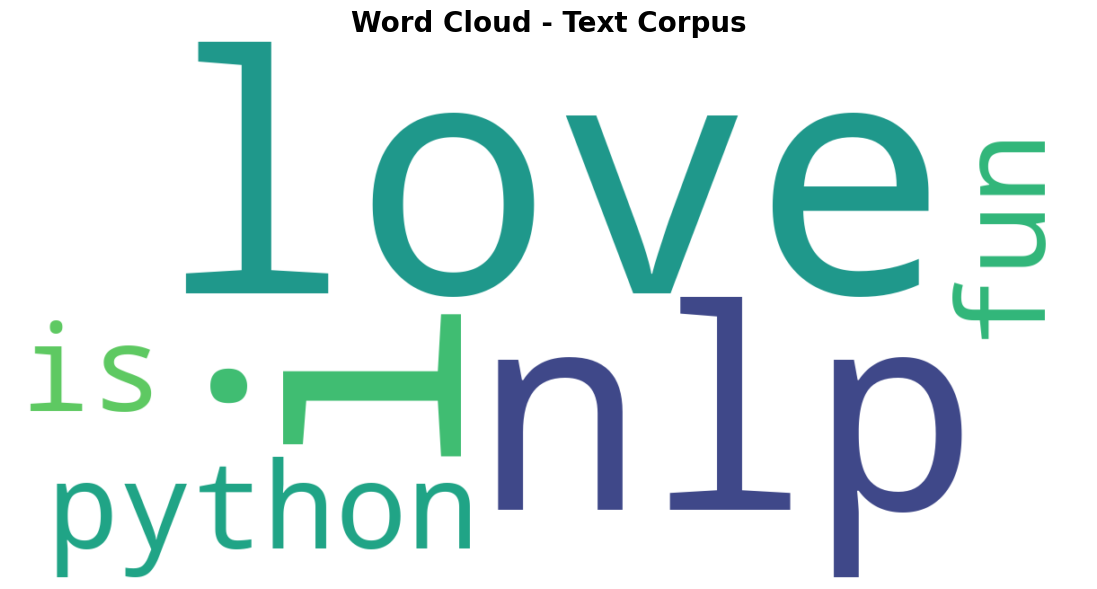


Top Five Most Frequent Words:
----------------------------------------
1. i → 2
2. love → 2
3. nlp → 2
4. python → 1
5. is → 1


In [5]:
# ================================================================
# EXERCISE 3: TEXT REPRESENTATION TECHNIQUES
# ACTIVITY 3: WORD CLOUD
# ================================================================
#
# Tasks:
# 1. Combine all documents into a single text.
# 2. Generate a Word Cloud.
# 3. Display the Word Cloud.
# 4. Identify the top five most frequent words.
# ================================================================


# ------------------------------------------------
# TASK 1: Import Required Libraries
# ------------------------------------------------

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter


# ------------------------------------------------
# Given Text Corpus
# ------------------------------------------------

corpus = [
    "I love NLP",
    "I love Python",
    "NLP is fun"
]

documents = ["D1", "D2", "D3"]


# ------------------------------------------------
# TASK 1: Combine All Documents into One Text
# ------------------------------------------------

combined_text = " ".join(corpus).lower()

print("Combined Text:")
print(combined_text)


# ------------------------------------------------
# Calculate Word Frequencies
# ------------------------------------------------

words = combined_text.split()

word_frequency = Counter(words)

print("\nWord Frequencies:")
for word, frequency in word_frequency.items():
    print(f"{word}: {frequency}")


# ------------------------------------------------
# TASK 2: Generate the Word Cloud
# ------------------------------------------------

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(word_frequency)


# ------------------------------------------------
# TASK 3: Display the Word Cloud
# ------------------------------------------------

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title(
    "Word Cloud - Text Corpus",
    fontsize=20,
    fontweight="bold"
)

plt.show()


# ------------------------------------------------
# TASK 4: Identify Top Five Most Frequent Words
# ------------------------------------------------

top_five_words = word_frequency.most_common(5)

print("\nTop Five Most Frequent Words:")
print("-" * 40)

for rank, (word, frequency) in enumerate(top_five_words, start=1):
    print(f"{rank}. {word} → {frequency}")